In [96]:
from openaq import OpenAQ as aq
import pandas as pd
import geopandas
import folium
#Load API
api = aq(api_key="703567a9b637449ffb21acf96659f4a58d69761753e4e1082ab6fb84232652de")

In [97]:
#Get the locations list for india. Limit argument is to make sure it covers all the available stations in india
locations = api.locations.list(
    countries_id=9,
    limit=1000
)

In [98]:
# Convert results to a list of dictionaries for Pandas
locs_data = [loc for loc in locations.results]
df = pd.DataFrame(locs_data)

Each entry in the sensor column is a list of dictionaries. Which looks like this

[{'id': 33,
  'name': 'co µg/m³',
  'parameter': {'id': 4,
   'name': 'co',
   'units': 'µg/m³',
   'display_name': 'CO mass'}}, 
 {'id': 32,
  'name': 'no2 µg/m³',
  'parameter': {'id': 5,
   'name': 'no2',
   'units': 'µg/m³',
   'display_name': 'NO₂ mass'}},
 {'id': 31,
  'name': 'pm10 µg/m³',
  'parameter': {'id': 1,
   'name': 'pm10',
   'units': 'µg/m³',
   'display_name': 'PM10'}},
 {'id': 34,
  'name': 'pm25 µg/m³',
  'parameter': {'id': 2,
   'name': 'pm25',
   'units': 'µg/m³',
   'display_name': 'PM2.5'}}]

In [105]:
import pandas as pd

# Current UTC time
now_utc = pd.Timestamp.now(tz="UTC")

# Define thresholds
recent_threshold = now_utc - pd.Timedelta(days=1)   # "today"
history_threshold = now_utc - pd.DateOffset(years=1)
# Sensor + monitor filter
filtered_df = df[df["sensors"].apply(has_all_required)]
filtered_df = filtered_df[filtered_df["is_monitor"] == True]

# Convert datetime columns
filtered_df["datetime_last_utc"] = pd.to_datetime(
    filtered_df["datetime_last"].str["utc"],
    errors="coerce",
    utc=True
)

filtered_df["datetime_first_utc"] = pd.to_datetime(
    filtered_df["datetime_first"].str["utc"],
    errors="coerce",
    utc=True
)

# Apply both conditions
filtered_df = filtered_df[
    (filtered_df["datetime_last_utc"] >= recent_threshold) &   # data today
    (filtered_df["datetime_first_utc"] <= history_threshold)   # data ≥ 1 years old
]

Found 588 locations with all 4 sensors which are CO, NO2, PM2.5, PM10, O3 and SO2

In [106]:
filtered_df

,id,name,locality,timezone,country,owner,provider,is_mobile,is_monitor,instruments,sensors,coordinates,bounds,distance,datetime_first,datetime_last,datetime_last_utc,datetime_first_utc
4,17,"R K Puram, Delhi - DPCC",None,Asia/Kolkata,"{'id': 9, 'code': 'IN', 'name': 'India'}","{'id': 8524, 'name': 'Delhi Pollution Control ...","{'id': 168, 'name': 'CPCB'}",False,True,"[{'id': 2, 'name': 'Government Monitor'}, {'id...","[{'id': 392, 'name': 'co µg/m³', 'parameter': ...","{'latitude': 28.563262, 'longitude': 77.186937}","(77.186937, 28.563262, 77.186937, 28.563262)",None,"{'utc': '2016-02-05T14:55:00Z', 'local': '2016...","{'utc': '2026-03-17T14:30:00Z', 'local': '2026...",2026-03-17 14:30:00+00:00,2016-02-05 14:55:00+00:00
5,50,"Punjabi Bagh, Delhi - DPCC",None,Asia/Kolkata,"{'id': 9, 'code': 'IN', 'name': 'India'}","{'id': 8524, 'name': 'Delhi Pollution Control ...","{'id': 168, 'name': 'CPCB'}",False,True,"[{'id': 2, 'name': 'Government Monitor'}, {'id...","[{'id': 12234791, 'name': 'co ppb', 'parameter...","{'latitude': 28.674045, 'longitude': 77.131023}","(77.131023, 28.674045, 77.131023, 28.674045)",None,"{'utc': '2016-02-05T14:55:00Z', 'local': '2016...","{'utc': '2026-03-17T14:30:00Z', 'local': '2026...",2026-03-17 14:30:00+00:00,2016-02-05 14:55:00+00:00
7,235,"Anand Vihar, New Delhi - DPCC",None,Asia/Kolkata,"{'id': 9, 'code': 'IN', 'name': 'India'}","{'id': 8524, 'name': 'Delhi Pollution Control ...","{'id': 168, 'name': 'CPCB'}",False,True,"[{'id': 2, 'name': 'Government Monitor'}, {'id...","[{'id': 12235605, 'name': 'co ppb', 'parameter...","{'latitude': 28.646835, 'longitude': 77.316032}","(77.316032, 28.646835, 77.316032, 28.646835)",None,"{'utc': '2016-02-05T14:15:00Z', 'local': '2016...","{'utc': '2026-03-17T14:30:00Z', 'local': '2026...",2026-03-17 14:30:00+00:00,2016-02-05 14:15:00+00:00
10,301,"Vikas Sadan, Gurugram - HSPCB",None,Asia/Kolkata,"{'id': 9, 'code': 'IN', 'name': 'India'}","{'id': 8529, 'name': 'Haryana State Pollution ...","{'id': 168, 'name': 'CPCB'}",False,True,"[{'id': 1, 'name': 'N/A'}, {'id': 2, 'name': '...","[{'id': 14258983, 'name': 'co ppb', 'parameter...","{'latitude': 28.4501238, 'longitude': 77.0263051}","(77.0263051, 28.4501238, 77.0263051, 28.4501238)",None,"{'utc': '2016-03-25T08:00:00Z', 'local': '2016...","{'utc': '2026-03-17T14:15:00Z', 'local': '2026...",2026-03-17 14:15:00+00:00,2016-03-25 08:00:00+00:00
14,407,"Zoo Park, Hyderabad - TSPCB",None,Asia/Kolkata,"{'id': 9, 'code': 'IN', 'name': 'India'}","{'id': 8533, 'name': 'Telangana State Pollutio...","{'id': 168, 'name': 'CPCB'}",False,True,"[{'id': 2, 'name': 'Government Monitor'}, {'id...","[{'id': 12235578, 'name': 'co ppb', 'parameter...","{'latitude': 17.349694, 'longitude': 78.451437}","(78.451437, 17.349694, 78.451437, 17.349694)",None,"{'utc': '2016-03-21T19:00:00Z', 'local': '2016...","{'utc': '2026-03-17T14:15:00Z', 'local': '2026...",2026-03-17 14:15:00+00:00,2016-03-21 19:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,3409525,"Trivenidevi Bhalotia College, Asansol - WBPCB",None,Asia/Kolkata,"{'id': 9, 'code': 'IN', 'name': 'India'}","{'id': 8523, 'name': 'West Bengal Pollution Co...","{'id': 168, 'name': 'CPCB'}",False,True,"[{'id': 2, 'name': 'Government Monitor'}, {'id...","[{'id': 12238679, 'name': 'co ppb', 'parameter...","{'latitude': 23.616515, 'longitude': 87.119133}","(87.119133, 23.616515, 87.119133, 23.616515)",None,"{'utc': '2025-02-18T20:15:00Z', 'local': '2025...","{'utc': '2026-03-17T14:15:00Z', 'local': '2026...",2026-03-17 14:15:00+00:00,2025-02-18 20:15:00+00:00
664,3409527,"SIPCOT Industrial Park, Perundurai - TNPCB",None,Asia/Kolkata,"{'id': 9, 'code': 'IN', 'name': 'India'}","{'id': 8540, 'name': 'Tamil Nadu Pollution Con...","{'id': 168, 'name': 'CPCB'}",False,True,"[{'id': 2, 'name': 'Government Monitor'}, {'id...","[{'id': 12238696, 'name': 'co ppb', 'parameter...","{'latitude': 11.258242, 'longitude': 77.552761}","(77.552761, 11.258242, 77.552761

In [104]:
#An interactive map of the available locations using foleum. You might have to wait some time for it to load completely. 

filtered_df["lat"] = filtered_df["coordinates"].apply(lambda x: x["latitude"])
filtered_df["lon"] = filtered_df["coordinates"].apply(lambda x: x["longitude"])

stations = filtered_df[["name", "lat", "lon"]]

import folium

m = folium.Map(location=[22, 80], zoom_start=5)  # center on India

for _, row in stations.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4,
        popup=row["name"],
        color="red",
        fill=True
    ).add_to(m)

m

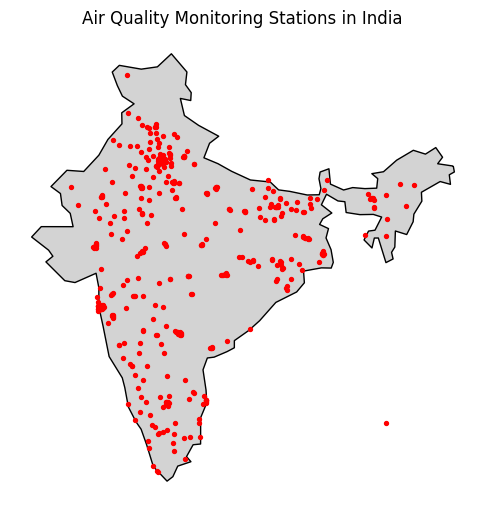

In [37]:
import geopandas as gpd
import geodatasets

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)
india = world[world["ADMIN"] == "India"]

import matplotlib.pyplot as plt

gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations.lon, stations.lat),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(6,8))

india.plot(ax=ax, color="lightgray", edgecolor="black")

gdf.plot(
    ax=ax,
    color="red",
    markersize=8
)

ax.set_title("Air Quality Monitoring Stations in India")
ax.set_axis_off()

plt.show()

## Getting data from sensors
- each sensor has a unique sensor ID
- We can get sensor IDs for each corresponding locations and use it to get the measurements

In [23]:
api.sensors.get(sensors_id=385).results
#give information about a sensor given the ID

[Sensor(id=385, name='co µg/m³', parameter=Parameter(id=4, name='co', units='µg/m³', display_name='CO mass', description=None), datetime_first=Datetime(utc='2016-02-05T14:15:00Z', local='2016-02-05T19:45:00+05:30'), datetime_last=Datetime(utc='2016-03-21T14:45:00Z', local='2016-03-21T20:15:00+05:30'), coverage=Coverage(expected_count=4, expected_interval='01:00:00', observed_count=126, observed_interval='31:30:00', percent_complete=3150.0, percent_coverage=3150.0, datetime_from=Datetime(utc='2016-02-05T14:15:00Z', local='2016-02-05T19:45:00+05:30'), datetime_to=Datetime(utc='2016-03-21T14:45:00Z', local='2016-03-21T20:15:00+05:30')), latest=LatestBase(datetime=Datetime(utc='2016-03-21T14:45:00Z', local='2016-03-21T20:15:00+05:30'), value=1300.0, coordinates=Coordinates(latitude=28.646835, longitude=77.316032)), summary=Summary(min=200.0, q02=None, q25=None, median=None, q75=None, q98=None, max=13600.0, sd=None, avg=1569.047619047619))]

In [40]:
help(api.measurements.list)

Help on method list in module openaq._sync.models.measurements:

list(sensors_id: int, data: Optional[Literal['measurements', 'hours', 'days', 'years']] = None, rollup: Optional[Literal['hourly', 'daily', 'monthly', 'yearly', 'hourofday', 'dayofweek', 'monthofyear']] = None, datetime_from: datetime.datetime | str | None = '2016-10-10', datetime_to: datetime.datetime | str | None = None, page: int = 1, limit: int = 1000) -> openaq.shared.responses.MeasurementsResponse method of openaq._sync.models.measurements.Measurements instance
    List air quality measurements based on provided filters.

    Args:
        sensors_id: The ID of the sensor for which measurements should be retrieved.
        data: The base measurement unit to query
        rollup: The period by which to rollup the base measurement data.
        datetime_from: Starting date for the measurement retrieval. Can be a datetime object or ISO-8601 formatted date or datetime string.
        datetime_to: Ending date for the mea

In [94]:
from datetime import datetime

# Get current local date and time and format it as ISO 8601 string
current_time = datetime.now().isoformat()
print(current_time)

hrly = api.measurements.list(sensors_id=1, rollup="hourly", datetime_from="2016-01-01", datetime_to="2026-01-01")
dat_list = [res for res in hrly.results]
dat = pd.DataFrame(dat_list)

2026-03-13T16:19:02.176546


In [96]:
dat

MeasurementsResponse(headers=Headers(x_ratelimit_limit=60, x_ratelimit_remaining=59, x_ratelimit_used=1, x_ratelimit_reset=60), meta=Meta(name='openaq-api', website='/', page=1, limit=1000, found=0), results=[])

In [140]:
import requests

url = "https://api.openaq.org/v3/sensors/12234782/measurements"

params = {
    "datetime_from": "2026-01-01",
    "limit":1000
}

headers = {
    "X-API-Key": "703567a9b637449ffb21acf96659f4a58d69761753e4e1082ab6fb84232652de"
}

r = requests.get(url, params=params, headers=headers)

data = r.json()
df = pd.json_normalize(data["results"])

In [142]:
df.head()

,value,coordinates,summary,flagInfo.hasFlags,parameter.id,parameter.name,parameter.units,parameter.displayName,period.label,period.interval,...,coverage.expectedCount,coverage.expectedInterval,coverage.observedCount,coverage.observedInterval,coverage.percentComplete,coverage.percentCoverage,coverage.datetimeFrom.utc,coverage.datetimeFrom.local,coverage.datetimeTo.utc,coverage.datetimeTo.local
0,1.94,None,None,False,102,co,ppb,None,raw,00:15:00,...,1,00:15:00,1,00:15:00,100.0,100.0,2025-12-31T19:00:00Z,2026-01-01T00:30:00+05:30,2025-12-31T19:15:00Z,2026-01-01T00:45:00+05:30
1,1.92,None,None,False,102,co,ppb,None,raw,00:15:00,...,1,00:15:00,1,00:15:00,100.0,100.0,2025-12-31T19:15:00Z,2026-01-01T00:45:00+05:30,2025-12-31T19:30:00Z,2026-01-01T01:00:00+05:30
2,1.82,None,None,False,102,co,ppb,None,raw,00:15:00,...,1,00:15:00,1,00:15:00,100.0,100.0,2025-12-31T19:30:00Z,2026-01-01T01:00:00+05:30,2025-12-31T19:45:00Z,2026-01-01T01:15:00+05:30
3,1.72,None,None,False,102,co,ppb,None,raw,00:15:00,...,1,00:15:00,1,00:15:00,100.0,100.0,2025-12-31T19:45:00Z,2026-01-01T01:15:00+05:30,2025-12-31T20:00:00Z,2026-01-01T01:30:00+05:30
4,1.69,None,None,False,102,co,ppb,None,raw,00:15:00,...,1,00:15:00,1,00:15:00,100.0,100.0,2025-12-31T20:00:00Z,2026-01-01T01:30:00+05:30,2025-12-31T20:15:00Z,2026-01-01T01:45:00+05:30


In [116]:
filtered_df["sensors"]

4      [{'id': 12234782, 'name': 'co ppb', 'parameter...
5      [{'id': 398, 'name': 'co µg/m³', 'parameter': ...
7      [{'id': 12235605, 'name': 'co ppb', 'parameter...
8      [{'id': 386, 'name': 'co µg/m³', 'parameter': ...
10     [{'id': 14258983, 'name': 'co ppb', 'parameter...
                             ...                        
717    [{'id': 15586068, 'name': 'co ppb', 'parameter...
718    [{'id': 15645471, 'name': 'co ppb', 'parameter...
719    [{'id': 15645483, 'name': 'co ppb', 'parameter...
720    [{'id': 15645495, 'name': 'co ppb', 'parameter...
721    [{'id': 15645507, 'name': 'co ppb', 'parameter...
Name: sensors, Length: 588, dtype: object